<a href="https://colab.research.google.com/github/redinbluesky/DeepLearning_Keypoint/blob/main/04_Deeplearning_트랜스포머_모델_사용.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 목차
* [Chapter 04_01_개요](#chapter04_01)
* [Chapter 04_02_토큰과_임베딩](#chapter04_02)
* [Chapter 04_03_분류미세튜닝](#chapter04_03)

## Chapter 04_01_개요<a class="anchor" id="chapter04_01"></a>
1. 어떤 트랜스포머 모델을 사용하지 결정하기 위해 모델을 검색해야 하는데 유명한 곳은 아래와 같다.
    - [Hugging Face](https://huggingface.co/models)
    - [TensorFlow Hub](https://tfhub.dev/)
    - [PyTorch Hub](https://pytorch.org/hub/)

2. 한국에서 개발한 허깅페이스 모델은 아래의 K-AI HUB에서 확인할 수 있다.
    - [K-AI HUB](https://www.kaihub.or.kr/)

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# 사전 훈련된 모델("microsoft/Phi-3-mini-4k-instruct")을 로드한다.
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",      # 모델이 GPU에서 실행되도록 설정
    torch_dtype="auto",     # 모델이 자동으로 최적의 데이터 타입을 선택하도록 설정
    trust_remote_code=False, # 모델이 사용자 정의 코드를 포함하는 경우 이를 신뢰하도록 설정 
)

tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    trust_remote_code=True, # 모델이 사용자 정의 코드를 포함하는 경우 이를 신뢰하도록 설정
)

In [2]:
# 트랜스포머에서 제공하는 pipline를 사용하여 모델을 로드한다.
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,  # 전체 텍스트를 반환하지 않도록 설정
    max_new_tokens=1000,      # 생성할 최대 토큰 수를 100으로 설정
    do_sample=False,          # 샘플링을 사용하여 텍스트를 생성하도록 설정
)

Device set to use cuda
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [ ]:
# 트랜스포머에 전달할 프롬프트를 정의한다.
#   role: "user" - 사용자의 입력을 나타냄
#   content: "Create a funny joke about chickens" - 사용자가 요청한 내용
message = [{"role":"user", "content":"Create a funny joke about chickens"}]

output = generator(message)
print(output)

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
# 한국에서 개발된 카카오 모델을 로드한다.
#   - kakaocorp/kanana-nano-2.1b-instruct
model = AutoModelForCausalLM.from_pretrained(
    "kakaocorp/kanana-nano-2.1b-instruct",
    device_map="cuda",      # 모델이 GPU에서 실행되도록 설정
    torch_dtype="auto",     # 모델이 자동으로 최적의 데이터 타입을 선택하도록 설정
    trust_remote_code=True, # 모델이 사용자 정의 코드를 포함하는 경우 이를 신뢰하도록 설정 
)

tokenizer = AutoTokenizer.from_pretrained(
    "kakaocorp/kanana-nano-2.1b-instruct",
    trust_remote_code=True, # 모델이 사용자 정의 코드를 포함하는 경우 이를 신뢰하도록 설정
    device_map="cuda"
)

`torch_dtype` is deprecated! Use `dtype` instead!


In [3]:
message = [{"role":"user", "content":"랭체인에 대해 알려줘"}]

output = generator(message)
print(output)

[{'generated_text': '랭체인(LangChain)은 자연어 처리(NLP)와 머신러닝 모델을 통합하여 다양한 애플리케이션에 유연하고 확장 가능한 솔루션을 제공하는 프레임워크입니다. 이 프레임워크는 특히 데이터 과학자, 개발자, 연구자들이 복잡한 NLP 작업을 쉽게 구현하고 배포할 수 있도록 설계되었습니다. 다음은 랭체인에 대한 주요 정보와 특징입니다:\n\n### 주요 특징\n\n1. **유연성과 확장성**:\n   - 다양한 NLP 모델을 쉽게 통합할 수 있습니다.\n   - 데이터 파이프라인을 구성하고 관리할 수 있는 유연한 아키텍처를 제공합니다.\n   - 대규모 데이터셋을 효율적으로 처리할 수 있는 기능을 포함하고 있습니다.\n\n2. **모듈화된 접근**:\n   - 데이터 준비, 모델 학습, 예측, 평가, 저장 및 배포를 하나의 프레임워크 내에서 관리할 수 있습니다.\n   - 각 단계를 독립적으로 확장하거나 교체할 수 있는 모듈화된 구조를 제공합니다.\n\n3. **다양한 모델 지원**:\n   - BERT, GPT, T5 등 다양한 NLP 모델을 지원합니다.\n   - 사용자 정의 모델도 쉽게 통합할 수 있습니다.\n\n4. **간편한 사용자 인터페이스**:\n   - 직관적이고 사용하기 쉬운 API를 제공하여, 개발자들이 복잡한 코드 없이도 쉽게 모델을 구축하고 배포할 수 있습니다.\n\n5. **데이터 관리**:\n   - 데이터 전처리, 저장, 로드, 변환 등의 기능을 제공하여 데이터 관리를 간소화합니다.\n   - 다양한 데이터 소스와 형식을 지원합니다.\n\n6. **배포 및 모니터링**:\n   - 모델을 쉽게 배포하고 모니터링할 수 있는 기능을 제공합니다.\n   - 클라우드 서비스와의 통합을 지원하여, 온프레미스 환경뿐만 아니라 클라우드 환경에서도 사용할 수 있습니다.\n\n### 주요 기능\n\n1. **데이터 준비**:\n   - 데이터 전처리, 정제, 변환을 위한 다양한 도구 제공.\n   - 데이터셋 로드 및 저

## Chapter 04_02_토큰과_임베딩<a class="anchor" id="chapter04_02"></a>
1. 토크나이져가 입력 토큰을 어떻게 분해하는지 확인한다.


In [4]:
# <|assistant|>: 모델이 응답을 생성하는 위치를 지정한다.
prompt = "사라에게 비극적인 원예사고에 대한 이메일을 작성해줘. 그 사고가 어떻게 방행하였는지 설명을 포함해서.<|assistant|>"

# return_tensors="pt": 리턴 타입을 파이터치 텐서로 지정한다.
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to("cuda")

input_ids

tensor([[128000,  56154,  51440, 102244,  75086, 110616, 103684, 102467, 103415,
          56154,  35495,  19954, 102597,  23955,  85767,  33177,  18359, 114839,
          34983,  59269,    246,     13,  55925,  33229,  35495,  20565, 112655,
          75908, 101066, 111320, 120279, 114942,  18359, 110097,  97237,  16134,
             91,  78191,     91,     29]], device='cuda:0')

In [10]:
# 코드를 다시 토큰으로 변환한다.
for id in input_ids[0]:
    print(tokenizer.decode(id))

<|begin_of_text|>
사
라
에게
 비
극
적인
 원
예
사
고
에
 대한
 이
메
일
을
 작성
해
�
�
.
 그
 사
고
가
 어떻게
 방
행
하였
는지
 설명
을
 포함
해서
.<
|
assistant
|
>


In [17]:
output = model(input_ids, max_new_tokens=100, do_sample=False)
print(output['logits'].shape)  # 출력 로짓의 형태를 확인한다.


torch.Size([1, 40, 128256])


In [5]:
output = generator(prompt)
print(output)

[{'generated_text': ' \n\n물론입니다. 다음은 사라(Sara)에게 보낼 비극적인 원예사고에 대한 이메일 예시입니다.\n\n---\n\n제목: 비극적인 원예사고에 대한 보고\n\n안녕하세요 사라,\n\n저는 당신의 원예 프로젝트를 돕기 위해 열심히 일해온 원예사 존 존스입니다. 최근 발생한 비극적인 원예사고에 대해 매우 안타깝고 유감스럽게 생각하며, 이에 대해 자세히 설명드리고자 합니다.\n\n지난 주말, 저희는 당신의 정원에서 새로운 식물들을 심고 가꾸는 작업을 진행했습니다. 특히, 새로운 다육식물들을 심는 과정에서 예기치 못한 사고가 발생했습니다. 작업 중, 저희는 다육식물의 뿌리가 깊지 않다는 것을 간과했습니다. 이로 인해 식물들이 심어진 흙이 불안정해졌고, 비가 내리기 시작하면서 흙이 무너져 내리기 시작했습니다.\n\n이 사고로 인해 다육식물의 뿌리가 손상되었고, 일부 식물들은 완전히 뽑혀버렸습니다. 또한, 작업 중에 사용한 도구들이 물에 젖어 미끄러워지면서 사고가 더 심화되었습니다. 이로 인해 작업자들 중 한 명이 다치게 되었고, 그 중 한 명은 심각한 부상을 입었습니다.\n\n저희는 이 사고를 예방하기 위해 최선을 다했지만, 예상치 못한 상황이 발생하면서 사고가 커졌습니다. 저희는 사고 후 즉시 응급조치를 취하고, 부상자들을 병원으로 이송했습니다. 또한, 사고 원인을 분석하고 재발 방지 대책을 마련하기 위해 모든 관련자들과 협력하고 있습니다.\n\n이 사고로 인해 많은 시간과 노력이 소요되었으며, 당신과 당신의 정원에 큰 피해를 입혔습니다. 이에 대해 깊은 사과를 드리며, 앞으로 더 신중하고 철저한 관리와 준비를 통해 이러한 사고가 재발하지 않도록 최선을 다하겠습니다.\n\n당신의 정원과 프로젝트에 대한 깊은 관심과 사랑에 감사드리며, 앞으로도 계속해서 함께 일할 수 있기를 바랍니다. 추가로 도움이 필요하시거나 우려사항이 있으시면 언제든지 말씀해 주세요. \n\n감사합니다.\n\n존 존스\n\n---\n\n이 이메일을 통해 사라에게

In [6]:
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 1792, padding_idx=128001)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=1792, out_features=3072, bias=False)
          (k_proj): Linear(in_features=1792, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1792, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=1792, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=1792, out_features=8064, bias=False)
          (up_proj): Linear(in_features=1792, out_features=8064, bias=False)
          (down_proj): Linear(in_features=8064, out_features=1792, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((1792,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((1792,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((1792

In [7]:
# 모델의 출력을 가져온다.
model_output = model.model(input_ids)
print(model_output[0].shape)  # 출력의 형태를 확인한다.
print(model_output)

torch.Size([1, 40, 1792])
BaseModelOutputWithPast(last_hidden_state=tensor([[[ 3.9062e+00, -3.9844e-01,  3.5312e+00,  ...,  2.6719e+00,
           1.8555e-01,  1.6016e+00],
         [-1.1953e+00,  1.2422e+00, -8.0859e-01,  ..., -3.1094e+00,
           1.4141e+00, -8.3008e-02],
         [-5.6250e+00, -7.0938e+00,  9.5703e-01,  ..., -1.1328e+00,
          -2.0020e-01,  6.9531e-01],
         ...,
         [-5.9062e+00, -4.4861e-03, -3.8750e+00,  ..., -4.6875e+00,
           4.1250e+00,  2.0312e+00],
         [-4.8438e+00,  1.3516e+00, -1.1621e-01,  ...,  4.7461e-01,
          -1.9531e+00,  3.8906e+00],
         [-1.5625e-01, -1.9609e+00, -4.8125e+00,  ...,  1.1875e+00,
           2.8125e+00, -1.0781e+00]]], device='cuda:0', dtype=torch.bfloat16,
       grad_fn=<MulBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLay

In [8]:
# inm_head에서 출력을 얻는다
im_head_output = model.lm_head(model_output[0])
print(im_head_output.shape)  # 출력의 형태를 확인한다.
print(im_head_output)

torch.Size([1, 40, 128256])
tensor([[[-8.2500e+00, -8.1875e+00, -1.0000e+00,  ..., -3.9062e-02,
          -3.4668e-02, -3.1128e-02],
         [-2.2168e-01,  7.8125e-01,  2.9219e+00,  ..., -4.3750e+00,
          -4.3750e+00, -4.3750e+00],
         [-1.7969e+00, -1.6641e+00, -6.5000e+00,  ..., -1.1375e+01,
          -1.1375e+01, -1.1375e+01],
         ...,
         [ 8.9453e-01,  5.9688e+00,  3.1719e+00,  ..., -9.1797e-01,
          -9.2188e-01, -9.2188e-01],
         [-6.3171e-03,  1.3281e+00,  2.4062e+00,  ..., -5.3906e-01,
          -5.3906e-01, -5.4297e-01],
         [-3.5625e+00, -1.7344e+00, -1.6211e-01,  ..., -3.6562e+00,
          -3.6562e+00, -3.6562e+00]]], device='cuda:0', dtype=torch.bfloat16,
       grad_fn=<UnsafeViewBackward0>)


In [9]:
# 로짓의 확률 점수를 얻는다.
#   ":": 모델의 출력에서 마지막 토큰의 로짓을 가져온다.
last_token_logits = im_head_output[:, -1, :]
print(last_token_logits.shape)  # 출력의 형태를 확인한다.
print(last_token_logits)

torch.Size([1, 128256])
tensor([[-3.5625, -1.7344, -0.1621,  ..., -3.6562, -3.6562, -3.6562]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<SelectBackward0>)


In [10]:
# 가장 확률이 높은 로짓을 찾는다.
#   argmax(dim=-1): 마지막 차원에서 가장 큰 값을 가진 인덱스를 반환한다.
token_id = last_token_logits.argmax(dim=-1)
print(token_id.shape)  # 출력의 형태를 확인한다.
print(token_id)

torch.Size([1])
tensor([4815], device='cuda:0')


In [11]:
# 토큰을 다시 텍스트로 변환한다.
decode_token = tokenizer.decode(token_id)
decode_token

' \n\n'

## Chapter 04_03_분류미세튜닝<a class="anchor" id="chapter04_01"></a>

In [3]:
#  분류 미세튜닝을 위한 데이터셋 다운로드
#  - 스팸여부 | 메시지
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_file_name_path = "./data/sms_spam_collection.zip"
data_file_name_path = "./data/SMSSpamCollection.tsv"
data_path = "./data"

# 파일 다운로드
if not os.path.exists(zip_file_name_path):
    urllib.request.urlretrieve(url, zip_file_name_path)

# 압축해제
if not os.path.exists(data_file_name_path):
   with zipfile.ZipFile(zip_file_name_path, "r") as zip_ref:
       zip_ref.extractall(data_path)
       # 파일 이름 변경
       os.rename("./data/SMSSpamCollection", "./data/SMSSpamCollection.tsv")




In [4]:
# 판다스로 SMSSpamCollection.tsv 파일을 읽어온다.
import pandas as pd

df = pd.read_csv(data_file_name_path, sep="\t", header=None, names=["label", "message"])
df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [18]:
# 허깅페이스에 등록된 한글 스팸메시지 분류 데이터셋
import pandas as pd

# "content"와 "class" 컬럼만 읽어온다.
df = pd.read_csv("hf://datasets/meal-bbang/Korean_message/lgaidataset.csv", usecols=["content", "class"])

# df의 행 숫자 카운트
print(df.shape[0])

# "label" 컬럼을 추가한다. class 값이 1이면 "ham", 2이면 "spam"으로 설정한다. 3이면 "promotion"으로 설정한다.
df["label"] = "promotion"
df.loc[df["class"] == 1, "label"] = 'ham'
df.loc[df["class"] == 2, "label"] = 'spam'

# class 컬럼을 삭제한다.
df.drop(columns=['class'], inplace=True)

# label 컬럼 값 중 "ham"과 "spam"만 남기고 나머지는 삭제한다.
df = df[df["label"].isin(["ham", "spam"])]

# df의 행 숫자 카운트
print(df.shape[0])

# "content" 컬럼을 "message"로 이름을 변경한다.
df.rename(columns={"content": "Text", "label": "Label"}, inplace=True)

# 컬럼의 순서를 "Label", "Text"로 변경한다.
df = df[["Label", "Text"]]


# 데이터 확인을 위해 상위 5개의 행을 출력한다.
df.head()

# 파일lgaidataset.csv을 저장한다.
df.to_csv("./data/lgaidataset.csv", index=False, sep="\t")

19009
16309


In [3]:
import pandas as pd

# ./data/lgaidataset.csv 파일을 판다스로 읽어온다.
df = pd.read_csv("./data/lgaidataset.csv", sep="\t")

df.head()

,Label,Text
0,spam,엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐?
1,spam,[국외발신]\n[코인원]\n고객님계정이\n해외IP에서\n로그인되였습니다.해외IP차단...
2,spam,엄마 입금받을수있는\n은행계좌번호\n하나랑 계좌등록\n본인인증땜에\n계좌 3자리\n...
3,spam,엄마 바빠?나지금\n핸드폰 고장나서 매장에 수리맡기고\n급한대로 예전에\n내명의로 ...
4,spam,엄마~ 바빠?\n엄마 나 급한 일이 좀 생겨서…\n지금 98만원만 입금해 줄 수 있...


In [36]:
# ham, spam 메시지 개수 출력
print(df['Label'].value_counts())

Label
spam    10531
ham      5778
Name: count, dtype: int64


In [4]:
# ham과 spam 메시지의 숫자가 같은 데이터 프레임을 만든다.
ham_df = df[df['Label'] == "ham"]
spam_df = df[df['Label'] == "spam"]

# spam 메시지의 숫자를 ham의 숫자와 동일하게 만든다.
ham_count = ham_df.shape[0]
spam_df = spam_df.sample(ham_count, random_state=123)

balanced_df = pd.concat([ham_df, spam_df])

print(balanced_df["Label"].value_counts())

Label
ham     5778
spam    5778
Name: count, dtype: int64


In [5]:
# ham이면 0, spam이면 1로 변환한다.
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})
print(balanced_df["Label"].value_counts())


Label
0    5778
1    5778
Name: count, dtype: int64


In [6]:
# 데이터 프레임을 섞는다.
# frac=1: 데이터 프레임의 모든 행을 섞는다.
# random_state=123: 난수 시드를 고정하여 동일한 결과를 얻도록 설정한다.
# reset_index(drop=True): 기존 인덱스를 제거하고 새로운 인덱스를 생성한다.
balanced_df = balanced_df.sample(frac=1, random_state=123).reset_index(drop=True)

In [7]:
# train, validation, test 데이터셋으로 0.7, 0.1, 0.2 비율로 나눈다.
train_size = int(0.7 * len(balanced_df))
val_size = int(0.1 * len(balanced_df))
test_size = len(balanced_df) - train_size - val_size

train_df = balanced_df[:train_size]
val_df = balanced_df[train_size:train_size + val_size]
test_df = balanced_df[train_size + val_size:]

# train.csv, validation.csv, test.csv 파일로 저장한다.
train_df.to_csv("./data/train.csv", index=False)
val_df.to_csv("./data/validation.csv", index=False)
test_df.to_csv("./data/test.csv", index=False)

In [8]:
# 패딩토큰이 있는지 확인한다.
print(tokenizer.pad_token)

# 패딩토큰의 아이디를 확인한다.
print(tokenizer.pad_token_id)

<|end_of_text|>
128001


In [9]:
test_df = pd.read_csv("./data/train.csv")
encoded_texts = [tokenizer.encode(text) for text in test_df["Text"]]
len(encoded_texts[0])

42

In [12]:
# 파이토치 데이터셋 클래스를 정의한다.
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=128001):
        self.data = pd.read_csv(csv_file)

        # 텍스트를 토큰화한다.
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]

        # max_length가 지정되지 않았다면 가징 긴 encoded_texts의 길이를 max_length로 설정한다.  
        if max_length is None:
            self.max_length = max(len(encoded_text) for encoded_text in self.encoded_texts)
        else: # max_length 보다 큰 리스트는 자른다.
            self.encoded_texts = [encoded_text[:max_length] for encoded_text in self.encoded_texts]

        # 가장 긴 리스트 길이에 맞추어 패딩(128001)을 추가한다.
        self.encoded_texts = [encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) for encoded_text in self.encoded_texts]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        encoded = self.encoded_texts[idx]
        label = self.data.iloc[idx]['Label']
        return (torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long))


In [13]:
import pandas as pd

train_dataset = SpamDataset(
    csv_file="./data/train.csv",
    max_length=None,
    tokenizer=tokenizer)
print("Max length of train_dataset:", train_dataset.max_length)

val_dataset = SpamDataset(
    csv_file="./data/validation.csv",
    max_length=None,
    tokenizer=tokenizer)
print("Max length of val_dataset:", val_dataset.max_length)

test_dataset = SpamDataset(
    csv_file="./data/test.csv",
    max_length=None,
    tokenizer=tokenizer)
print("Max length of test_dataset:", test_dataset.max_length)

Max length of train_dataset: 850
Max length of val_dataset: 775
Max length of test_dataset: 853


In [14]:
# 데이터 로더를 생성한다.
from torch.utils.data import DataLoader

num_workers = 0 # 데이터 로더에서 사용할 워커 수를 설정한다. 0이면 메인 프로세스에서 데이터를 로드한다.
batch_size = 4
torch.manual_seed(123)  # 랜덤 시드를 고정하여 동일한 결과를 얻도록 설정한다.

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,  # 데이터를 섞어서 로드하도록 설정한다.
    num_workers=num_workers,
    drop_last=True  # 마지막 배치가 batch_size보다 작으면 버린다.
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,  # 검증 데이터는 섞지 않고 로드하도록 설정한다
    num_workers=num_workers,
    drop_last=False  # 마지막 배치가 batch_size보다 작아도 버리지 않는다.
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,  # 테스트 데이터는 섞지 않고 로드하도록 설정한다
    num_workers=num_workers,
    drop_last=False  # 마지막 배치가 batch_size보다 작아도 버리지 않는다.
)

In [13]:
# 마지막 배치 텐서 차원 출력
for input_bath, tartget_bath in train_loader:
    pass

print("Input batch shape:", input_bath.shape)
print("Target batch shape:", tartget_bath.shape)

Input batch shape: torch.Size([8, 850])
Target batch shape: torch.Size([8])


In [14]:
print(f"{len(train_loader)}개 훈련배치")
print(f"{len(val_loader)}개 검증배치")
print(f"{len(test_loader)}개 테스트배치")

1011개 훈련배치
145개 검증배치
289개 테스트배치


In [15]:
# 모델이 일관적인 텍스트를 생성하는지 확인한다.
text_1 = "Every effort moves you"
generated_text_1 = generator(text_1, max_new_tokens=50, do_sample=False)
print(generated_text_1)

[{'generated_text': " to the right direction. –\xa0user12345\n@user12345: That's a great piece of advice! I'll definitely keep that in mind. However, I'm a bit confused about the context of your comment. Is it related to"}]


In [16]:
# 모델이 미세튜닝전 스팸을 구분할 수 있는지 확인한다.
text_2 = "'우리 ca 안되서꺠열 사 가입진행둘러보시라고가입동시 삼  지금바로!hha***.com' 문장이 스팸인지 아닌지 '예', '아니오'로 대답해줘 "
generated_text_2 = generator(text_2, max_new_tokens=50, do_sample=False)
print(generated_text_2)

[{'generated_text': ' 예.  스팸입니다.  아니오.  스팸으로 판단됩니다. 이유는 문장이 비정상적으로 길고, 의심스러운 URL이 포함되어 있으며, 일반적인 대화 형식'}]


In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM
# 한국에서 개발된 카카오 모델을 로드한다.
#   - kakaocorp/kanana-nano-2.1b-instruct
model = AutoModelForCausalLM.from_pretrained(
    "kakaocorp/kanana-nano-2.1b-instruct",
    device_map="cuda",      # 모델이 GPU에서 실행되도록 설정
    torch_dtype="auto",     # 모델이 자동으로 최적의 데이터 타입을 선택하도록 설정
    trust_remote_code=True, # 모델이 사용자 정의 코드를 포함하는 경우 이를 신뢰하도록 설정 
)

tokenizer = AutoTokenizer.from_pretrained(
    "kakaocorp/kanana-nano-2.1b-instruct",
    trust_remote_code=True, # 모델이 사용자 정의 코드를 포함하는 경우 이를 신뢰하도록 설정
    device_map="cuda"
)

`torch_dtype` is deprecated! Use `dtype` instead!


In [10]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 1792, padding_idx=128001)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=1792, out_features=3072, bias=False)
          (k_proj): Linear(in_features=1792, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1792, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=1792, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=1792, out_features=8064, bias=False)
          (up_proj): Linear(in_features=1792, out_features=8064, bias=False)
          (down_proj): Linear(in_features=8064, out_features=1792, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((1792,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((1792,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((1792

In [ ]:
model.model.embed_tokens


Linear(in_features=1792, out_features=128256, bias=False)

In [15]:
import torch
# 모델의 출력을 이진 클래스(스팸 또는 스팸 아님)을 매핑하는 출력 레이어로 교체한다.
#   - (lm_head): Linear(in_features=1792, out_features=128256, bias=False)

# 모델을 동결한다.
for param in model.parameters():
    param.requires_grad = False

# 미세 튜닝을 위해 모델의 마지막 층을 새로운 부류해드로 교체한다.
torch.manual_seed(123)
num_class = 2

# 입력 개수는 1792개 출력은 2개인 선형층으로 lm_head를 교체한다.
model.lm_head = torch.nn.Linear(in_features=1792, out_features=num_class, bias=False)

# 마지막 rotary_emb, norm을 훈련 가능하도록 설정한다.
for param in model.model.norm.parameters():
    param.requires_grad = True

for param in model.model.rotary_emb.parameters():
    param.requires_grad = True    


In [43]:
model.model.embed_tokens.weight.shape[0]

128256

In [16]:
# 입력 텍스트를 토큰화한다.
text_2 = "'우리 ca 안되서꺠열 사 가입진행둘러보시라고가입동시 삼  지금바로!hha***.com' 문장이 스팸인지 아닌지 '예', '아니오'로 대답해줘 "
inputs = tokenizer(text_2, return_tensors="pt").to("cuda")
input_ids = inputs['input_ids'].to(torch.float32)
print("입력 차원: ", input_ids.shape)

# 입력하였을 때 출력이 2개의 클래스(스팸 또는 스팸 아님)로 매핑되는지 확인한다.
model = model.to(inputs["input_ids"].device)

# lm_head와 본체 dtype/device를 맞춘다. (BFloat16 vs Float 충돌 방지)
model.lm_head = model.lm_head.to(
    device=inputs["input_ids"].device,
    dtype=next(model.model.parameters()).dtype
)

with torch.no_grad():
    print(inputs["input_ids"])
    output = model(
        input_ids=inputs["input_ids"].long(),
        attention_mask=inputs["attention_mask"]
    )
print("출력 차원: ", output['logits'].shape)
# [:, -1, :] 에서 ":" 의미는 모든 배치를 
print("마지막 출력 토큰: ", output['logits'][:, -1, :])

입력 차원:  torch.Size([1, 59])
tensor([[128000,      6, 126818,   2211,  96270,  65219,  27796,    166,    118,
            254,  55055,  33229, 127287,  86351, 101066, 124201,  61394,  42771,
          30426, 105771,  20565,  44966,  58189,  30426, 107455,    220, 109296,
         101974,  17835,      0,     71,   4317,  12488,     13,    884,      6,
          54535, 114784,  80307,  45780,    234,    116, 117469, 116548,  22035,
            364, 103415,    518,    364,  54059,  84136,  58368,      6,  17835,
         126958,  34983,  59269,    246,    220]], device='cuda:0')
출력 차원:  torch.Size([1, 59, 2])
마지막 출력 토큰:  tensor([[-4.8125,  2.0781]], device='cuda:0', dtype=torch.bfloat16)


In [17]:
# 마지막 토큰을 스팸, 스팸 아님의 확률로 사용한다. (0: 스팸 아님, 1: 스팸)
#   - 마지막 토큰은 앞 토큰의 정보를 모두 포함하고 있으므로 마지막 토큰을 통해 스팸과 스팸 아님을 구분한다.
# torch.argmax를 사용하여 마지막 출력 토큰에서 가장 높은 확률을 가진 클래스 인덱스를 가져온다.
label = torch.argmax(output['logits'][:, -1, :], dim=-1)
label

tensor([1], device='cuda:0')

In [18]:
# 정확도를 측정할 함수를 만든다.
def cal_accuracy_loader(data_loader, model, device, num_batch=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batch is None:
        num_batch = len(data_loader)
    else:
        num_batch = min(num_batch, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batch:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                output = model(input_ids=input_batch)
                logits = output['logits'][:, -1, :]

            predicated_label = torch.argmax(logits, dim=-1)

            num_examples += predicated_label.shape[0]
            correct_predictions += (predicated_label == target_batch).sum().item()
        else:
            break

        print(f"Batch {i+1}/{num_batch}: Accuracy = {correct_predictions / num_examples:.4f}")

    return correct_predictions / num_examples


In [31]:
# 정확도 출력
device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)

torch.manual_seed(123)

train_accuracy = cal_accuracy_loader(train_loader, model, device, num_batch=10)
print(f"Train Accuracy: {train_accuracy:.4f}")

val_accuracy = cal_accuracy_loader(val_loader, model, device, num_batch=10) 
print(f"Validation Accuracy: {val_accuracy:.4f}")

test_accuracy = cal_accuracy_loader(test_loader, model, device, num_batch=10)
print(f"Test Accuracy: {test_accuracy:.4f}")


Batch 1/10: Accuracy = 0.3750
Batch 2/10: Accuracy = 0.4375
Batch 3/10: Accuracy = 0.5000
Batch 4/10: Accuracy = 0.5312
Batch 5/10: Accuracy = 0.5000
Batch 6/10: Accuracy = 0.4792
Batch 7/10: Accuracy = 0.4643
Batch 8/10: Accuracy = 0.4844
Batch 9/10: Accuracy = 0.4861
Batch 10/10: Accuracy = 0.4625
Train Accuracy: 0.4625
Batch 1/10: Accuracy = 0.3750
Batch 2/10: Accuracy = 0.4375
Batch 3/10: Accuracy = 0.3750
Batch 4/10: Accuracy = 0.4375
Batch 5/10: Accuracy = 0.5000
Batch 6/10: Accuracy = 0.5417
Batch 7/10: Accuracy = 0.5357
Batch 8/10: Accuracy = 0.5469
Batch 9/10: Accuracy = 0.5417
Batch 10/10: Accuracy = 0.5500
Validation Accuracy: 0.5500
Batch 1/10: Accuracy = 0.7500
Batch 2/10: Accuracy = 0.8125
Batch 3/10: Accuracy = 0.7083
Batch 4/10: Accuracy = 0.6875
Batch 5/10: Accuracy = 0.6750
Batch 6/10: Accuracy = 0.6667
Batch 7/10: Accuracy = 0.6071
Batch 8/10: Accuracy = 0.5781
Batch 9/10: Accuracy = 0.5694
Batch 10/10: Accuracy = 0.5750
Test Accuracy: 0.5750


In [19]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    output = model(input_ids=input_batch)
    logits = output['logits'][:, -1, :]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [20]:
# 손실 함수를 정의한다.
#   - CrossEntropyLoss: 다중 클래스 분류 문제에서 사용되는 손실 함수
def cal_loss_loader(data_loader, model, device, num_batch=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batch is None:
        num_batch = len(data_loader)
    else:
        num_batch = min(num_batch, len(data_loader))

    for i, (input_batch, tartget_batch) in enumerate(data_loader):
        if i < num_batch:
            loss = calc_loss_batch(input_batch, tartget_batch, model, device)
            total_loss += loss.item()
        else:
            break

        print(f"Batch {i+1}/{num_batch}: Loss = {total_loss / (i+1):.4f}")

    return total_loss / num_batch
            

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# 손실을 계산한다.
with torch.no_grad():
    train_loss = cal_loss_loader(train_loader, model, device, num_batch=2)
    print(f"Train Loss: {train_loss:.4f}")

    val_loss = cal_loss_loader(val_loader, model, device, num_batch=2)
    print(f"Validation Loss: {val_loss:.4f}")

    test_loss = cal_loss_loader(test_loader, model, device, num_batch=2)
    print(f"Test Loss: {test_loss:.4f}")

Batch 1/2: Loss = 0.0042
Batch 2/2: Loss = 1.1193
Train Loss: 1.1193
Batch 1/2: Loss = 3.2031
Batch 2/2: Loss = 2.6719
Validation Loss: 2.6719
Batch 1/2: Loss = 2.4219
Batch 2/2: Loss = 1.2134
Test Loss: 1.2134


In [23]:
# 모델 평가 함수
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = cal_loss_loader(train_loader, model, device, num_batch=eval_iter)
        val_loss = cal_loss_loader(val_loader, model, device, num_batch=eval_iter)
    model.train()
    return train_loss, val_loss

In [24]:
# 모델 학습 함수를 정의한다.
def train_classification_model(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter):

    # 손실 및 처리하한 샘플 수 리스트 초기화
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    example_seen, global_step = 0, -1

    # 메인 학습 루프
    for epoch in range(num_epochs):
        model.train() # 모델 훈련모드로 전환

        for i, (input_batch, target_batch) in enumerate(train_loader):
            optimizer.zero_grad() # 이전 배치에서 얻은 손실 재설정
            loss = calc_loss_batch(input_batch, target_batch, model, device) # 손실 계산.
            loss.backward() # 손실 그레이디언트 계산
            optimizer.step() # 손실 그레이드언트를 사용하여 모델 가중치 업데이트
            example_seen += input_batch.size(0) # 처리한 샘플 수 업데이트
            global_step += 1 # 전역 스텝 수 업데이트

            # 평가 주기마다 검증 손실 및 정확도 계산
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{global_step}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        # 각 에포크 후 정확도 계산
        train_accuracy = cal_accuracy_loader(train_loader, model, device, num_batch=eval_iter)
        val_accuracy = cal_accuracy_loader(val_loader, model, device, num_batch=eval_iter)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Accuracy: {train_accuracy:.4f}, Val Accuracy: {val_accuracy:.4f}")

    return train_losses, val_losses, train_accs, val_accs, example_seen

In [25]:
import time

device = "cuda" if torch.cuda.is_available() else "cpu"

start_time = time.time()

torch.manual_seed(123)

# 모델 학습을 위한 옵티마이저를 정의한다.
#   - AdamW: Adam 옵티마이저의 변형으로, 가중치 감쇠(weight decay)를 적용하여 과적합을 방지한다.
#   - lr=5e-5: 학습률을 5e-5로 설정한다.
#   - weight_decay=0.1: 가중치 감쇠를 0.1로 설정한다. 
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)

num_epochs = 2
train_losses, val_losses, train_accs, val_accs, example_seen = train_classification_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs,
    eval_freq=50,  # 평가 주기: 50 스텝마다 평가
    eval_iter=2    # 평가 시 사용할 배치 수: 2
)

Batch 1/2: Loss = 4.6250
Batch 2/2: Loss = 4.0469
Batch 1/2: Loss = 2.9375
Batch 2/2: Loss = 2.4609
Epoch [1/2], Step [0], Train Loss: 4.0469, Val Loss: 2.4609
Batch 1/2: Loss = 0.6016
Batch 2/2: Loss = 0.8398
Batch 1/2: Loss = 0.2412
Batch 2/2: Loss = 0.4878
Epoch [1/2], Step [50], Train Loss: 0.8398, Val Loss: 0.4878
Batch 1/2: Loss = 0.3652
Batch 2/2: Loss = 0.3594
Batch 1/2: Loss = 0.2617
Batch 2/2: Loss = 0.4609
Epoch [1/2], Step [100], Train Loss: 0.3594, Val Loss: 0.4609
Batch 1/2: Loss = 0.3438
Batch 2/2: Loss = 0.3838
Batch 1/2: Loss = 0.3086
Batch 2/2: Loss = 0.4512
Epoch [1/2], Step [150], Train Loss: 0.3838, Val Loss: 0.4512
Batch 1/2: Loss = 0.4258
Batch 2/2: Loss = 0.4043
Batch 1/2: Loss = 0.2891
Batch 2/2: Loss = 0.4531
Epoch [1/2], Step [200], Train Loss: 0.4043, Val Loss: 0.4531
Batch 1/2: Loss = 0.5117
Batch 2/2: Loss = 0.5566
Batch 1/2: Loss = 0.2432
Batch 2/2: Loss = 0.4399
Epoch [1/2], Step [250], Train Loss: 0.5566, Val Loss: 0.4399
Batch 1/2: Loss = 0.5195
Batch 

In [26]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # 훈련 및 검증 손실을 에포크에 따라 그립니다.
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # 처리한 샘플 수를 위해 두 번째 x축을 만듭니다.
    ax2 = ax1.twiny()  # 동일한 y축을 공유하는 두 번째 x축을 만듭니다.
    ax2.plot(examples_seen, train_values, alpha=0)  # 눈금 정렬을 위한 보이지 않는 그래프
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # 공간을 확보하기 위해 레이아웃을 조정합니다.
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

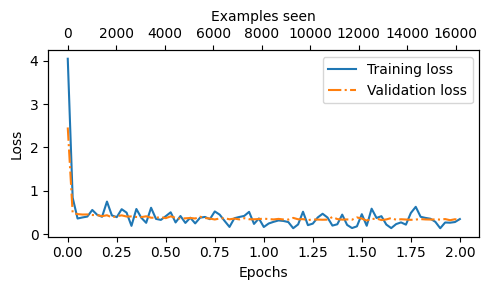

In [27]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, example_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)


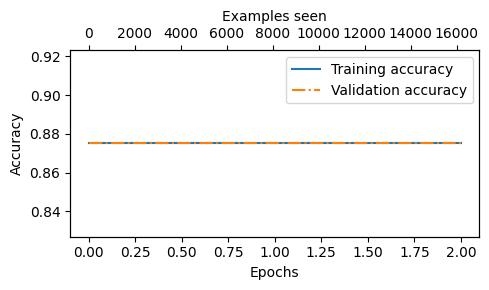

In [28]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, example_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

In [39]:
train_accuracy = cal_accuracy_loader(train_loader, model, device, num_batch=100)
val_accuracy = cal_accuracy_loader(val_loader, model, device, num_batch=100)
test_accuracy = cal_accuracy_loader(test_loader, model, device, num_batch=100)

print(f"훈련 정확도: {train_accuracy*100:.2f}%")
print(f"검증 정확도: {val_accuracy*100:.2f}%")
print(f"테스트 정확도: {test_accuracy*100:.2f}%")

Batch 1/100: Accuracy = 1.0000
Batch 2/100: Accuracy = 0.9375
Batch 3/100: Accuracy = 0.9167
Batch 4/100: Accuracy = 0.9375
Batch 5/100: Accuracy = 0.9500
Batch 6/100: Accuracy = 0.9583
Batch 7/100: Accuracy = 0.9464
Batch 8/100: Accuracy = 0.9531
Batch 9/100: Accuracy = 0.9583
Batch 10/100: Accuracy = 0.9625
Batch 11/100: Accuracy = 0.9545
Batch 12/100: Accuracy = 0.9583
Batch 13/100: Accuracy = 0.9519
Batch 14/100: Accuracy = 0.9375
Batch 15/100: Accuracy = 0.9333
Batch 16/100: Accuracy = 0.9297
Batch 17/100: Accuracy = 0.9338
Batch 18/100: Accuracy = 0.9306
Batch 19/100: Accuracy = 0.9276
Batch 20/100: Accuracy = 0.9250
Batch 21/100: Accuracy = 0.9286
Batch 22/100: Accuracy = 0.9205
Batch 23/100: Accuracy = 0.9130
Batch 24/100: Accuracy = 0.9115
Batch 25/100: Accuracy = 0.8950
Batch 26/100: Accuracy = 0.8894
Batch 27/100: Accuracy = 0.8843
Batch 28/100: Accuracy = 0.8795
Batch 29/100: Accuracy = 0.8750
Batch 30/100: Accuracy = 0.8792
Batch 31/100: Accuracy = 0.8831
Batch 32/100: Acc

In [29]:
# 모델을 사용해 스팸 메시지인지 아닌지 확인해주는 함수
def classify_message(text, model, tokenizer, device, max_length=None, pad_token_id=128001):
    model.eval() 

    input_ids = tokenizer.encode(text)
    support_context_length = model.model.embed_tokens.weight.shape[0]

    # 너무 긴 시퀸스는 자른다.
    input_ids = input_ids[: min(max_length, support_context_length - 1)]

    # 가장 긴 시퀸스 길이에 맞추어 패딩을 추가한다.
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_ids=input_tensor)
        logits = output['logits'][:, -1, :]
        predicted_label = torch.argmax(logits, dim=-1).item()

    return "spam" if predicted_label == 1 else "ham"

In [30]:
test_texts = ("[국제발신]잘못된 주소로 인해 배송에 실패했습니다. 정보를 업데이트하세요.http://hwanaa.bealuty.com",)
print(f"'{test_texts[0]}' 메시지의 분류 결과: {classify_message(test_texts[0], model, tokenizer, device, max_length=256)}"  )

'[국제발신]잘못된 주소로 인해 배송에 실패했습니다. 정보를 업데이트하세요.http://hwanaa.bealuty.com' 메시지의 분류 결과: spam
